# BLOOM — protótipo F0 (gêmeo digital offline)

**Equipe Supra · Jump Start 2026 · Missão 2 — Economia Circular Inteligente**

Este notebook executa, sobre dados públicos de baterias de íon-lítio, o motor proposto no
*Dossiê do Projeto*: **laudo de saúde sem ciclagem completa → gates de segurança → destino de maior
valor por bateria, com incerteza declarada e a conta de cada decisão.**

É a fase **F0** do dossiê (gêmeo digital offline, sem hardware novo) e responde, com dados, aos dois
primeiros testes de falsificação da seção 5:

1. *Com os dados que o BMS e o carregador já produzem, dá para prever o estado com erro útil para decisão?*
2. *O roteamento recomendaria segunda vida em quantidade suficiente, ou a reciclagem domina?*

E, a partir da resposta ao segundo, mede duas perguntas derivadas: **até que ponto da vida ainda vale
realocar** a bateria (seção 10) e **quanto vale pagar por reparo** antes de decidir o destino (seção 11).

| Módulo do dossiê | O que está aqui | Base na literatura |
|---|---|---|
| Health Intelligence | SOH P10/P50/P90 fora da amostra, vida residual | Wei et al. 2022; Kumar et al. 2023; Liu et al. 2024 |
| Gates de segurança | vetos 1-D antes da otimização | Lai et al. 2021 §3.2.3; Li et al. 2024; Geng et al. 2026 §6 |
| Lifecycle Router | VPL por destino sob incerteza, valor da informação | Guan et al. 2025 §4.2.2; Kumar et al. 2023 |
| Garantia como produto | prêmio derivado da probabilidade de falha | Dossiê §3.4 (caso Relectrify) |
| Battery Passport | continuidade do histórico e procedência | Guan et al. 2025 §3 |

> **O que este protótipo não é.** Não é validação em pack automotivo, não usa Ni-MH, e a camada
> econômica roda sobre um **perfil de premissas** (`bloom/config.py`), não sobre cotações. O perfil
> usado aqui é o `bev_revisado` — a revisão de preços de 18/09/2026 registrada em
> [`PREMISSAS.md`](../PREMISSAS.md). As limitações estão no fim, com números.

In [1]:
import sys, warnings
from dataclasses import replace
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from bloom import pipeline as P
from bloom.config import DEST, profile_settings
from bloom.extract import PACKS, SECOND_LIFE_ORIGIN
from bloom.health import FEATURE_SETS
from bloom.router import route, laudo_markdown

# Perfil de produto (bloom/config.py::profile_settings, revisão de premissas de 18/09/2026 — PREMISSAS.md).
# Só a camada econômica muda entre perfis; saúde, gates e modelo de estresse são os mesmos.
PERFIL = "bev_revisado"
ST = profile_settings(PERFIL)
DESTINATIONS = ST.destinations

pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})
GROUP_COLOR = {"regular_cc": "#2a6f97", "regular_random": "#61a5c2", "recommissioned": "#a98467",
               "second_life": "#d1495b"}
GROUP_LABEL = {"regular_cc": "1ª vida · corrente constante", "regular_random": "1ª vida · carga aleatória",
               "recommissioned": "1ª vida · carga muda ao longo da vida", "second_life": "2ª vida · células remontadas"}

## 1. Os dados

**NASA/UCF Randomized & Recommissioned Battery Dataset** (Fricke, Nascimento & Viana, 2023) — a escolha
da seção 8.1 da análise de referências: é o único que contém o ciclo de decisão inteiro, inclusive o
"depois": células sobreviventes de packs aposentados foram remontadas em packs de **segunda vida**.

- 26 packs de 2 células 18650 (2,5 Ah nominais) em série, ciclados até falhar;
- missões de descarga em corrente constante (5–19 A) ou aleatória, carga CC-CV, repousos;
- a cada ~30–60 h, uma **descarga de referência a 2,5 A** mede a capacidade: é o rótulo de SOH.

Os CSVs brutos (3,2 GB) viram uma tabela de 9.613 ciclos com `scripts/build_dataset.py`.

In [2]:
d = P.load_cycles()
packs = (d.groupby("pack")
          .agg(grupo=("group", "first"), ciclos=("cycle", "size"), referências=("is_ref", "sum"),
               corrente_A=("i_mean", lambda s: s[s > 4].median()), SOH_inicial=("soh", "first"),
               SOH_final=("soh", "last"), ciclos_eq_totais=("cum_efc", "max")))
print(f"{len(d)} ciclos, {d['pack'].nunique()} packs")
packs.sort_values(["grupo", "corrente_A"])

9613 ciclos, 26 packs


,grupo,ciclos,referências,corrente_A,SOH_inicial,SOH_final,ciclos_eq_totais
pack,,,,,,,
03,recommissioned,418,21,7.539,0.997,0.739,344.851
24,recommissioned,622,33,9.660,0.985,0.702,496.671
12,recommissioned,622,32,9.838,0.984,0.733,506.084
02,recommissioned,415,20,13.648,0.984,0.742,342.339
33,recommissioned,474,24,13.722,0.983,0.727,385.899
25,recommissioned,421,20,14.936,0.997,0.771,354.064
53,recommissioned,209,11,15.025,0.981,0.827,185.461
32,recommissioned,355,17,15.144,0.980,0.757,297.914
11,regular_cc,865,43,9.732,0.981,0.731,718.967


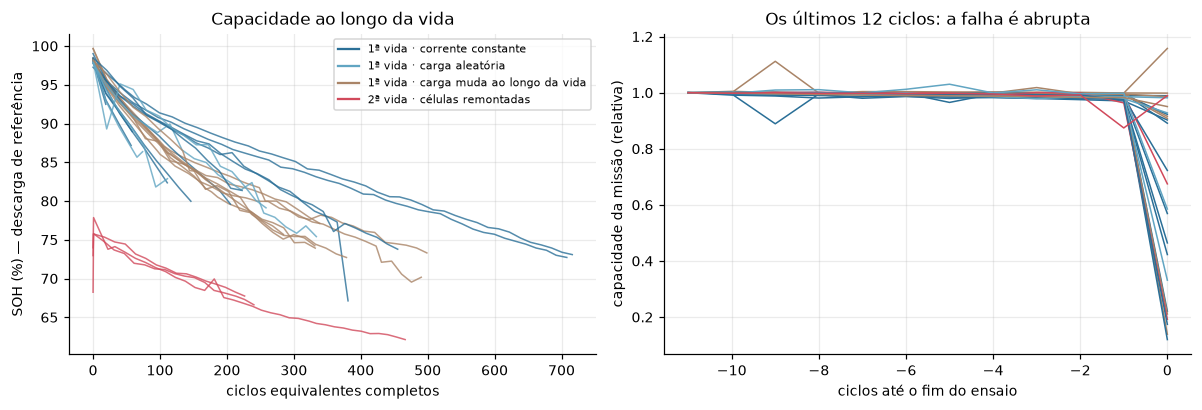

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for pack, g in d[d["is_ref"] & (d["dis_ah"] > 1)].groupby("pack"):
    grp = g["group"].iloc[0]
    axes[0].plot(g["cum_efc"], g["soh"] * 100, "-", color=GROUP_COLOR[grp], lw=1, alpha=.8)
for grp, c in GROUP_COLOR.items():
    axes[0].plot([], [], color=c, label=GROUP_LABEL[grp])
axes[0].set(xlabel="ciclos equivalentes completos", ylabel="SOH (%) — descarga de referência",
            title="Capacidade ao longo da vida")
axes[0].legend(fontsize=7)
last = d[~d["is_ref"]].groupby("pack").tail(12)
for pack, g in last.groupby("pack"):
    axes[1].plot(np.arange(-len(g) + 1, 1), g["dis_ah"] / g["dis_ah"].iloc[0], color=GROUP_COLOR[g["group"].iloc[0]], lw=1)
axes[1].set(xlabel="ciclos até o fim do ensaio", ylabel="capacidade da missão (relativa)",
            title="Os últimos 12 ciclos: a falha é abrupta")
plt.tight_layout()

**Primeira leitura.** O fim de vida aqui não é "SOH chegou a 80%": os packs morrem de forma **abrupta**,
muitas vezes com 80–90% de SOH, e nada na capacidade dos ciclos anteriores avisa. É a primeira evidência,
nos dados, de que **nota única de saúde não basta** (Lai et al. 2021; Dossiê §3.5) — e de que a vida
residual precisa sair com incerteza larga.

Atenção à escala: 16 A em uma célula de 2,5 Ah são **6,4 C**; as missões chegam a ~100 °C. É um ensaio
acelerado, e tudo o que for transportado para destinos reais (0,2–1 C) é extrapolação declarada.

## 2. Laudo sem ciclagem completa: o que dá para medir rápido

Três conjuntos de features, do mais barato ao mais caro, mais uma linha de base:

| conjunto | o que exige | exemplos |
|---|---|---|
| **idade** (linha de base) | só o "hodômetro" | ciclos equivalentes, corrente de uso |
| **laudo rápido** | ~20 min de bancada, sem histórico | resistência aparente no pulso de 2/10/60/120 s, aquecimento em 2 min, janela de carga 7,6→8,4 V, queda de tensão no repouso pós-carga |
| **telemetria BMS** | o que o BMS já registra no uso | laudo rápido + aquecimento da missão, relaxação pós-uso, histórico acumulado |
| **ciclo completo** (limite superior) | descarga até o corte e carga do vazio | capacidade medida na própria missão |

O último é justamente o ensaio lento que o BLOOM quer evitar; entra só como teto de referência.

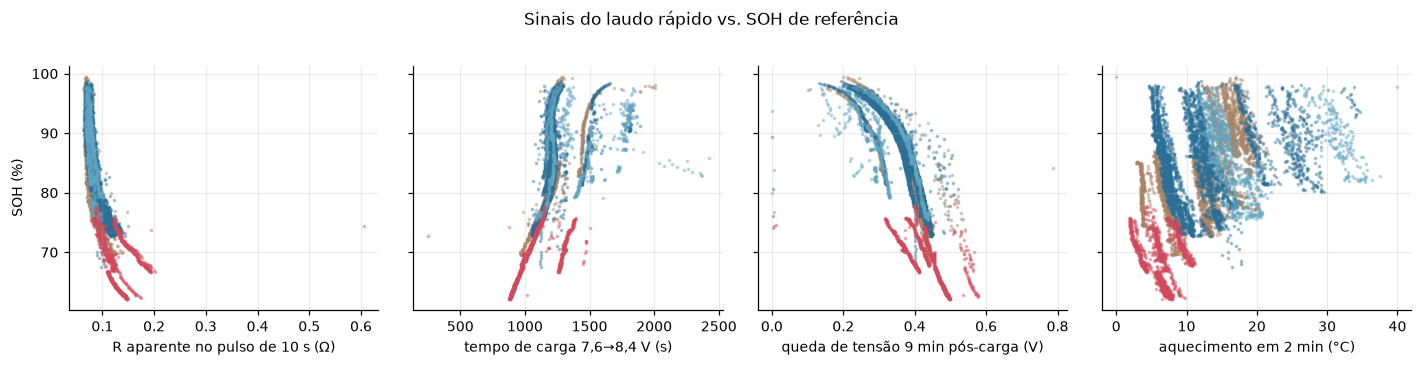

In [4]:
tr = d[(~d["is_ref"]) & (~d["label_extrapolated"]) & d["soh"].notna()]
feats = [("r_app_10s", "R aparente no pulso de 10 s (Ω)"), ("chg_t_7v6_8v4", "tempo de carga 7,6→8,4 V (s)"),
         ("post_chg_drop_540s", "queda de tensão 9 min pós-carga (V)"), ("dT_120s", "aquecimento em 2 min (°C)")]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), sharey=True)
for ax, (f, lab) in zip(axes, feats):
    for grp, g in tr.groupby("group"):
        ax.scatter(g[f], g["soh"] * 100, s=2, alpha=.35, color=GROUP_COLOR[grp])
    ax.set(xlabel=lab)
axes[0].set_ylabel("SOH (%)")
plt.suptitle("Sinais do laudo rápido vs. SOH de referência", y=1.02)
plt.tight_layout()

## 3. Health Intelligence: SOH com incerteza declarada

Regressão quantílica (P10/P50/P90, gradient boosting) com **calibração conformal** balanceada por pack.
Toda métrica abaixo é **fora da amostra por pack inteiro** (GroupKFold): o pack avaliado nunca esteve no treino.
Isso é mais duro do que dividir ciclos aleatoriamente, e é o que acontece quando chega uma bateria nova.

Wei, Han & Li (2022) tratam o erro do modelo como distribuição (cadeia de Markov sobre faixas de erro);
aqui o mesmo papel é cumprido pelo intervalo calibrado — que depois vira preço de garantia (seção 7).

*A célula abaixo treina 13 dobras × 3 quantis × 3 conjuntos; leva alguns minutos.*

In [5]:
bench, bench_data = P.benchmark_soh(d)
cols = ["MAE", "P90 |erro|", "cobertura P10–P90", "largura média"]
print("Erro em pontos percentuais de SOH; cobertura alvo do intervalo = 80%")
bench[bench["grupo"] == "todos"].set_index("conjunto")[["n_features"] + cols]

Erro em pontos percentuais de SOH; cobertura alvo do intervalo = 80%


,n_features,MAE,P90 |erro|,cobertura P10–P90,largura média
conjunto,,,,,
idade (linha de base),2.0,5.287,10.948,0.719,14.984
laudo rápido,13.0,1.677,3.565,0.783,4.796
telemetria BMS,21.0,1.517,2.999,0.754,3.957
ciclo completo (limite superior),25.0,0.617,1.238,0.803,2.549


In [6]:
by_group = bench[bench["grupo"] != "todos"].pivot(index="grupo", columns="conjunto", values="MAE")
cov = bench[bench["grupo"] != "todos"].pivot(index="grupo", columns="conjunto", values="cobertura P10–P90")
display(Markdown("**MAE por grupo (p.p.)**")); display(by_group.round(2))
display(Markdown("**Cobertura do intervalo P10–P90 por grupo**")); display(cov.round(2))

**MAE por grupo (p.p.)**

conjunto,ciclo completo (limite superior),idade (linha de base),laudo rápido,telemetria BMS
grupo,,,,
recommissioned,0.29,3.08,0.94,0.84
regular_cc,0.59,5.82,1.17,0.99
regular_random,0.91,3.74,1.45,1.09
second_life,1.31,10.46,5.05,4.94


**Cobertura do intervalo P10–P90 por grupo**

conjunto,ciclo completo (limite superior),idade (linha de base),laudo rápido,telemetria BMS
grupo,,,,
recommissioned,0.93,0.98,0.95,0.93
regular_cc,0.77,0.60,0.84,0.80
regular_random,0.74,0.89,0.88,0.81
second_life,0.60,0.25,0.14,0.14


**Leitura.**

- O **laudo rápido** reduz o erro da linha de base de idade em ~3×, sem histórico e sem descarregar o
  pack, com intervalo que cobre o valor real perto dos 80% prometidos nos packs de primeira vida.
- O **ciclo completo** fica abaixo de 1 p.p. — comparável ao MAE < 0,8% de Wei et al. (2022), que também
  usa curva de descarga de referência. A distância entre os dois é o preço de não ciclar.
- **Packs de segunda vida quebram o modelo**: erro de vários p.p. e cobertura muito abaixo de 80%.
  O modelo **superestima** o SOH desses packs. A explicação física é a do "efeito barril"
  (Wang et al. 2023): em um pack remontado, a capacidade segue a **pior** célula, enquanto
  resistência e aquecimento refletem a **média** das duas. É o mesmo problema que a Relectrify viu
  (até 32% de diferença de SOH entre células; Dossiê §3.1).

Um laudo que erra com confiança é pior do que nenhum. Duas respostas no desenho:

In [7]:
engine = P.Engine(d)   # previsões fora da amostra para todas as missões, gates e modelo de estresse
rows = d.loc[engine.soh.index]
lab = (~rows["label_extrapolated"]) & rows["soh"].notna()
sl = lab & (rows["group"] == "second_life") & engine.soh["anchored"]
from bloom.health import metrics
cmp = pd.DataFrame({
    "laudo rápido puro": metrics(rows.loc[sl, "soh"].to_numpy(), engine.soh_raw.loc[sl]),
    "ancorado no ensaio de recomissão": metrics(rows.loc[sl, "soh"].to_numpy(), engine.soh.loc[sl]),
}).T[cols]
display(Markdown("**Packs de segunda vida — efeito de um único ensaio de referência na recomissão**"))
cmp

**Packs de segunda vida — efeito de um único ensaio de referência na recomissão**

,MAE,P90 |erro|,cobertura P10–P90,largura média
laudo rápido puro,5.063,10.884,0.153,6.843
ancorado no ensaio de recomissão,2.981,5.855,0.579,9.856


Fração de missões de 2ª vida acima do limite, por pack:
{'13': 0.02, '36': 0.23, '54': 1.0}


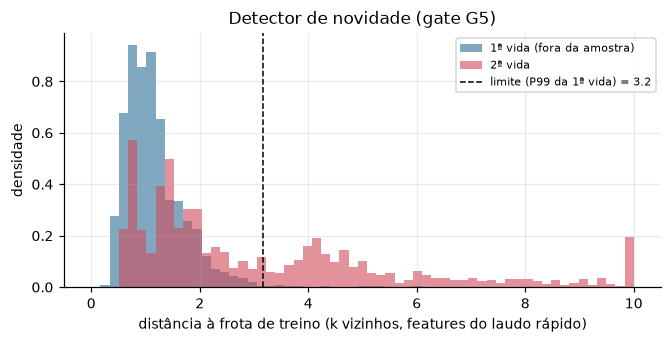

In [8]:
fl = rows["group"] != "second_life"
nov = engine.novelty
fig, ax = plt.subplots(figsize=(7, 3))
bins = np.linspace(0, 10, 60)
ax.hist(nov[fl].clip(upper=10), bins=bins, alpha=.6, color="#2a6f97", density=True, label="1ª vida (fora da amostra)")
ax.hist(nov[~fl].clip(upper=10), bins=bins, alpha=.6, color="#d1495b", density=True, label="2ª vida")
ax.axvline(engine.ref.novelty_limit, color="k", ls="--", lw=1, label=f"limite (P99 da 1ª vida) = {engine.ref.novelty_limit:.1f}")
ax.set(xlabel="distância à frota de treino (k vizinhos, features do laudo rápido)", ylabel="densidade",
       title="Detector de novidade (gate G5)")
ax.legend(fontsize=7)
print("Fração de missões de 2ª vida acima do limite, por pack:")
print((nov[~fl] > engine.ref.novelty_limit).groupby(rows.loc[~fl, "pack"]).mean().round(2).to_dict())

1. **Ensaio de recomissão como âncora.** Um único ensaio de referência quando o pack é remontado — que
   a UL 1974 já exige como avaliação individual — e o laudo rápido passa a acompanhar a *variação* a
   partir dele. O erro cai à ordem de 3 p.p.; o intervalo é recalibrado com os outros packs remontados
   (só há três: a calibração é frágil e isso fica declarado).
2. **Gates de procedência e novidade (G5, G6).** O passaporte informa que o pack foi remontado; o detector
   de novidade sinaliza packs fora da distribuição de treino. Nos dois casos o laudo diz **inconclusivo** e
   pede ensaio, em vez de devolver um número confiante.

O detector sozinho não pega todos (o pack 13 parece "normal" nas features). Por isso a procedência
registrada — a **continuidade** que o dossiê põe como diferencial — importa mais do que o algoritmo.

## 4. Vida residual: honestidade sobre o que não é previsível

Vida residual (ciclos equivalentes até a falha), fora da amostra: MAE 58, cobertura P10–P90 81%, largura média 227


[Text(0.5, 0, 'ciclos equivalentes até a falha (real)'),
 Text(0, 0.5, 'previsto (P50)'),
 (0.0, 800.0),
 (0.0, 800.0),
 Text(0.5, 1.0, 'Vida residual prevista vs. real')]

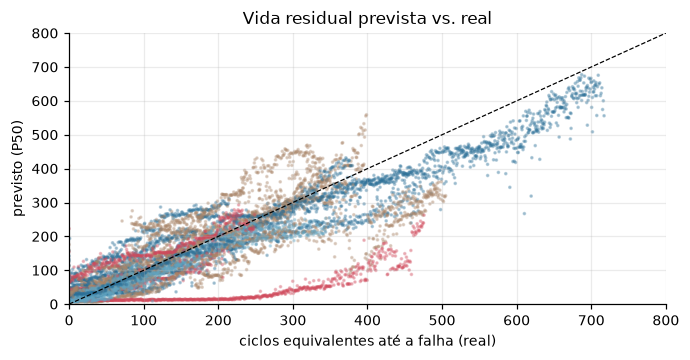

In [9]:
r = engine.rul
y = rows["efc_to_eol"]
m = metrics(y.to_numpy(), r, scale=1)
print(f"Vida residual (ciclos equivalentes até a falha), fora da amostra: MAE {m['MAE']:.0f}, "
      f"cobertura P10–P90 {m['cobertura P10–P90']:.0%}, largura média {m['largura média']:.0f}")
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(y, r["p50"], s=2, alpha=.3, c=[GROUP_COLOR[g] for g in rows["group"]])
ax.plot([0, 800], [0, 800], "k--", lw=.8)
ax.set(xlabel="ciclos equivalentes até a falha (real)", ylabel="previsto (P50)", xlim=(0, 800), ylim=(0, 800),
       title="Vida residual prevista vs. real")

O modelo de vida residual acerta a ordem de grandeza e a cobertura do intervalo, mas a largura é grande:
como a falha é abrupta, **o estado atual não diz exatamente quando o pack vai morrer**. Nos 10 ciclos antes
da falha, nem a inclinação da capacidade nem a resistência mudam o bastante para avisar (isso aparece de novo
no gate G4). É um achado importante para o pitch: **sensoriamento extra (gás, deformação, H2/H3 do dossiê)
tem valor justamente onde os sinais elétricos silenciam** — a revisão de Geng et al. (2026) mede avisos de
deformação 6–11 min antes da fuga térmica, contra segundos para tensão/temperatura.

## 5. Gates de segurança

Segurança como filtro unidimensional **antes** de qualquer conta econômica (Lai et al. 2021, §3.2.3).

| gate | sinal | efeito |
|---|---|---|
| G1 autoaquecimento | aquecimento em 2 min **não explicado por I²R**, em relação à linha de base do próprio pack | veta todo reuso |
| G2 resistência | R aparente / R de pack novo | restringe destinos de potência |
| G3 relaxação pós-carga | queda de tensão em 9 min de repouso (proxy de autodescarga) | restringe backup |
| G4 joelho | fade dos últimos 15 ciclos / fade médio do pack | veta segunda vida |
| G5 incerteza e novidade | largura do intervalo, distância à frota | laudo inconclusivo |
| G6 procedência | pack remontado sem ensaio de recomissão | laudo inconclusivo |

Por que G1 compara o pack **com ele mesmo**: o offset do termopar varia ±11 °C entre packs do dataset.
Um limite absoluto de frota mediria a montagem do sensor, não a bateria.

modelo térmico dT_2min ~ I, I²R, T0: coeficientes [0.599 0.461 0.023]
deriva térmica P99 da frota saudável = 1.83 °C -> limite de veto 2.83 °C
R de pack novo = 71 mΩ; limite de relaxação pós-carga = 480 mV


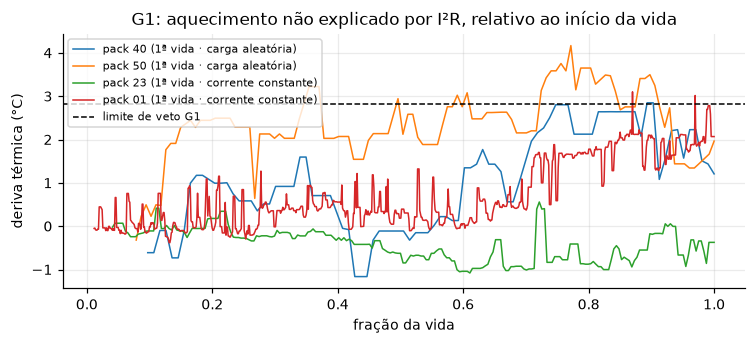

In [10]:
ref = engine.ref
print(f"modelo térmico dT_2min ~ I, I²R, T0: coeficientes {np.round(ref.details['thermal_coef_[I, I2R, T0]'], 3)}")
print(f"deriva térmica P99 da frota saudável = {ref.details['thermal_drift_p99']:.2f} °C -> limite de veto {ref.thermal_drift_limit:.2f} °C")
print(f"R de pack novo = {ref.r_new*1000:.0f} mΩ; limite de relaxação pós-carga = {ref.self_discharge_limit*1000:.0f} mV")

from bloom.safety import thermal_drift
fig, ax = plt.subplots(figsize=(8, 3))
for pack in ["40", "50", "23", "01"]:
    g = engine.d[(engine.d["pack"] == pack) & (~engine.d["is_ref"])]
    dr = [thermal_drift(g.iloc[:i]) for i in range(1, len(g) + 1)]
    ax.plot(g["cycle"] / g["cycle"].max(), dr, label=f"pack {pack} ({GROUP_LABEL[g['group'].iloc[0]]})", lw=1)
ax.axhline(ref.thermal_drift_limit, color="k", ls="--", lw=1, label="limite de veto G1")
ax.set(xlabel="fração da vida", ylabel="deriva térmica (°C)", title="G1: aquecimento não explicado por I²R, relativo ao início da vida")
ax.legend(fontsize=7)

## 6. Lifecycle Router: o destino de cada bateria

Para cada pack, em seis momentos da vida, o roteador:

1. aplica os gates (vetos e restrições, com a evidência numérica);
2. elimina destinos cujo requisito não é atendido (SOH mínimo, resistência);
3. simula 4.000 cenários de SOH e vida no destino e calcula o **VPL** de cada destino restante:
   venda do produto de 2ª vida (proporcional à vida entregue) − reembalagem − frete de carga perigosa −
   certificação − **prêmio de garantia** (probabilidade de falhar dentro da garantia × valor) + reciclagem
   descontada no fim;
4. recomenda o maior VPL esperado, informa em quantos cenários ele venceu e o **valor da informação**
   de um ensaio completo — se for maior que o custo do ensaio, o laudo manda ensaiar antes de decidir.

**Vida no destino.** O dataset é acelerado (≈4–8 C). O fade por ciclo cresce exponencialmente com a
corrente; ajustamos essa relação e a extrapolamos para a taxa C de cada destino, mais fade calendárico.
Dois cenários:

- **fade**: só o fade de capacidade limita a vida;
- **conservador**: também limita pela vida até a falha abrupta observada, sem creditar vida extra abaixo
  da menor corrente ensaiada.

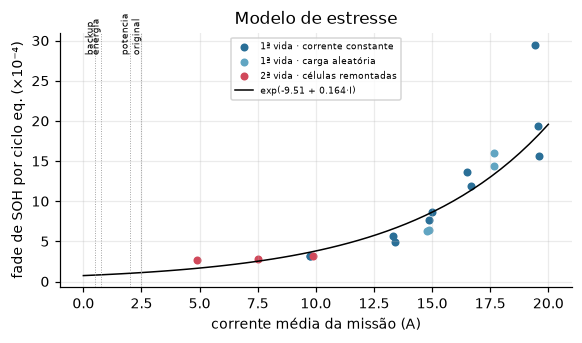

In [11]:
st = engine.stress
fig, ax = plt.subplots(figsize=(6, 3))
for grp, g in st.points.groupby("group"):
    ax.scatter(g["i_mean"], g["fade_per_efc"] * 1e4, color=GROUP_COLOR[grp], label=GROUP_LABEL[grp], s=18)
xs = np.linspace(0, 20, 50)
ax.plot(xs, st.fade(xs) * 1e4, "k-", lw=1, label=f"exp({st.a:.2f} + {st.b:.3f}·I)")
for dst in DESTINATIONS[:-1]:
    ax.axvline(dst.c_rate * 2.5, color="#999", lw=.6, ls=":")
    ax.text(dst.c_rate * 2.5, ax.get_ylim()[1] * .92, dst.key, rotation=90, fontsize=6, ha="right")
ax.set(xlabel="corrente média da missão (A)", ylabel="fade de SOH por ciclo eq. (×10⁻⁴)", title="Modelo de estresse")
ax.legend(fontsize=6)

**Qual conjunto de preços.** As premissas econômicas vêm de um **perfil de produto**
(`config.profile_settings`). Este notebook roda o perfil `bev_revisado`, a revisão de preços de
18/09/2026 documentada em [`PREMISSAS.md`](../PREMISSAS.md): pack de reposição de elétrico a
R$ 1.250/kWh (apurado de R$ 1.167–1.336/kWh) e sistema estacionário instalado a R$ 3.100/kWh (ponto
médio de R$ 2.700–3.500/kWh). São preços de imprensa, de confiança média — mais defensáveis que os
R$ 900 e R$ 1.800/kWh do perfil `v0_ilustrativo`, que a primeira versão usava, mas ainda não são
cotações. Só a camada econômica muda entre perfis: saúde, gates e modelo de estresse são os mesmos.

In [12]:
display(Markdown(pd.DataFrame([{
    "destino": x.label, "SOH mín.": x.soh_min, "sai com SOH": x.soh_eol, "R máx. (× novo)": x.r_growth_max,
    "taxa C": x.c_rate, "ciclos/ano": x.cycles_per_year, "produto novo R$/kWh": x.new_product_brl_kwh,
    "fator de preço": x.price_factor, "reembalagem R$/kWh": x.repack_brl_kwh, "garantia (anos)": x.warranty_years}
    for x in DESTINATIONS]).to_markdown(index=False)))
display(Markdown(f"**Premissas econômicas do perfil `{PERFIL}`** (editáveis em `bloom/config.py`)"))
ST.economics.as_dict()

| destino                                                     |   SOH mín. |   sai com SOH |   R máx. (× novo) |   taxa C |   ciclos/ano |   produto novo R$/kWh |   fator de preço |   reembalagem R$/kWh |   garantia (anos) |
|:------------------------------------------------------------|-----------:|--------------:|------------------:|---------:|-------------:|----------------------:|-----------------:|---------------------:|------------------:|
| Continuar na aplicação de origem (tração)                   |       0.85 |          0.8  |               1.3 |      1   |          250 |                  1250 |             0.75 |                   60 |                 1 |
| 2ª vida · potência (empilhadeira, troca de bateria de moto) |       0.78 |          0.7  |               1.5 |      0.8 |          300 |                  1400 |             0.6  |                  250 |                 2 |
| 2ª vida · energia estacionária (BESS comercial/residencial) |       0.65 |          0.55 |               2.2 |      0.3 |          330 |                  3100 |             0.55 |                  450 |                 4 |
| 2ª vida · backup / nobreak (baixa ciclagem)                 |       0.6  |          0.5  |               2.5 |      0.2 |           24 |                   600 |             0.5  |                  200 |                 3 |
| Reciclagem (recuperação de material)                        |       0    |          0    |             inf   |      0   |            0 |                     0 |             0    |                    0 |                 0 |

**Premissas econômicas do perfil `bev_revisado`** (editáveis em `bloom/config.py`)

{'pack_kwh': 10.0,
 'new_price_index': 1.0,
 'logistics_brl_kwh': 60.0,
 'certification_brl_kwh': 40.0,
 'bloom_test_brl_pack': 150.0,
 'reference_test_brl_pack': 800.0,
 'material_value_brl_kwh': 110.0,
 'recycling_process_brl_kwh': 80.0,
 'discount_rate': 0.12,
 'warranty_loading': 1.3}

### Três laudos

Um pack jovem, um pack de primeira vida no fim, e um pack de segunda vida.

In [13]:
for pack, frac in [("23", 0.1), ("01", 0.9), ("54", 0.5)]:
    c = engine.decision_points(pack, (frac,))[0]
    display(Markdown(laudo_markdown(engine.laudo(pack, c, ST))))
    display(Markdown("---"))

## Laudo BLOOM · pack 23 · ciclo 25

**SOH** P50 95.7% (intervalo 80%: 91.4% – 97.4%)  
**Vida residual no uso atual**: 289 ciclos equivalentes (P10 178)

### 1. Gates de segurança

| gate | status | evidência | fonte |
|---|---|---|---|
| G1 autoaquecimento | **ok** | aquecimento em 2 min de pulso não explicado por I²R: -0.1 °C sobre a linha de base do próprio pack (limite 2.8 °C) | Li et al. 2024; Geng et al. 2026 §6.1 |
| G2 resistência | **ok** | R aparente (pulso 10 s) = 69 mΩ = 0.97× o pack novo da frota | Guan et al. 2025 §4.2.2; Seger et al. 2022 |
| G3 relaxação pós-carga | **ok** | queda de tensão em 9 min de repouso pós-carga = 276 mV (limite 480 mV; proxy de autodescarga) | Dossiê §3.5; Wang et al. 2023 |
| G4 joelho de degradação | **sem dado** | histórico curto demais para medir inclinação |  |
| G5 incerteza e novidade | **ok** | intervalo P10–P90 de SOH = 6.0 p.p.; distância à frota de treino = 0.9 (limite 3.2) | Wei et al. 2022 (erro como distribuição) |

### 2. Destinos

| destino | elegível | VPL médio (R$) | VPL P10 | vida P50 (anos) | P(falha na garantia) | prêmio garantia | P(melhor) |
|---|---|---|---|---|---|---|---|
| Continuar na aplicação de origem (tração) | sim | 2,472 | 1,433 | 3.0 | 0% | 44 | 87% |
| 2ª vida · potência (empilhadeira, troca de bateria de moto) | sim | 1,252 | -490 | 4.1 | 4% | 370 | 13% |
| 2ª vida · energia estacionária (BESS comercial/residencial) | sim | -7,325 | -10,462 | 4.3 | 42% | 8,810 | 0% |
| 2ª vida · backup / nobreak (baixa ciclagem) | sim | -256 | -358 | 10.0 | 0% | 2 | 0% |
| Reciclagem (recuperação de material) | sim | -300 | -300 | — | — | 0 | 0% |

### 3. Recomendação

**Continuar na aplicação de origem (tração)** — escolhido em 87% dos cenários simulados.
Valor da informação de um ensaio completo: R$ 54 (ensaio custa R$ 800) → decisão pode ser tomada com o laudo rápido.

---

## Laudo BLOOM · pack 01 · ciclo 774

**SOH** P50 74.3% (intervalo 80%: 72.9% – 76.1%)  
**Vida residual no uso atual**: 93 ciclos equivalentes (P10 44)

### 1. Gates de segurança

| gate | status | evidência | fonte |
|---|---|---|---|
| G1 autoaquecimento | **ok** | aquecimento em 2 min de pulso não explicado por I²R: +2.0 °C sobre a linha de base do próprio pack (limite 2.8 °C) | Li et al. 2024; Geng et al. 2026 §6.1 |
| G2 resistência | **restringe** | R aparente (pulso 10 s) = 109 mΩ = 1.54× o pack novo da frota | Guan et al. 2025 §4.2.2; Seger et al. 2022 |
| G3 relaxação pós-carga | **ok** | queda de tensão em 9 min de repouso pós-carga = 440 mV (limite 480 mV; proxy de autodescarga) | Dossiê §3.5; Wang et al. 2023 |
| G4 joelho de degradação | **ok** | fade dos últimos 15 ciclos = -0.4× o fade médio do próprio pack | Guan et al. 2025 §4.1.3 |
| G5 incerteza e novidade | **ok** | intervalo P10–P90 de SOH = 3.2 p.p.; distância à frota de treino = 1.9 (limite 3.2) | Wei et al. 2022 (erro como distribuição) |

### 2. Destinos

| destino | elegível | VPL médio (R$) | VPL P10 | vida P50 (anos) | P(falha na garantia) | prêmio garantia | P(melhor) |
|---|---|---|---|---|---|---|---|
| Continuar na aplicação de origem (tração) | não | -9,946 | -9,946 | 0.0 | 100% | 9,046 | 0% |
| 2ª vida · potência (empilhadeira, troca de bateria de moto) | não | -11,259 | -11,582 | 0.6 | 100% | 8,106 | 0% |
| 2ª vida · energia estacionária (BESS comercial/residencial) | sim | -21,348 | -21,894 | 0.6 | 100% | 16,452 | 0% |
| 2ª vida · backup / nobreak (baixa ciclagem) | sim | -1,270 | -1,953 | 8.7 | 6% | 176 | 0% |
| Reciclagem (recuperação de material) | sim | -300 | -300 | — | — | 0 | 100% |

**Destinos eliminados e por quê:**
- *Continuar na aplicação de origem (tração)*: G2 resistência: R aparente (pulso 10 s) = 109 mΩ = 1.54× o pack novo da frota; SOH P50 74% abaixo do mínimo do destino (85%)
- *2ª vida · potência (empilhadeira, troca de bateria de moto)*: G2 resistência: R aparente (pulso 10 s) = 109 mΩ = 1.54× o pack novo da frota; SOH P50 74% abaixo do mínimo do destino (78%)

### 3. Recomendação

**Reciclagem (recuperação de material)** — escolhido em 100% dos cenários simulados.
Valor da informação de um ensaio completo: R$ 0 (ensaio custa R$ 800) → decisão pode ser tomada com o laudo rápido.

---

## Laudo BLOOM · pack 54 · ciclo 178

**SOH** P50 73.8% (intervalo 80%: 61.8% – 79.3%)  
**Vida residual no uso atual**: 153 ciclos equivalentes (P10 56)

### 1. Gates de segurança

| gate | status | evidência | fonte |
|---|---|---|---|
| G1 autoaquecimento | **ok** | aquecimento em 2 min de pulso não explicado por I²R: +0.7 °C sobre a linha de base do próprio pack (limite 2.8 °C) | Li et al. 2024; Geng et al. 2026 §6.1 |
| G2 resistência | **restringe** | R aparente (pulso 10 s) = 157 mΩ = 2.22× o pack novo da frota | Guan et al. 2025 §4.2.2; Seger et al. 2022 |
| G3 relaxação pós-carga | **ok** | queda de tensão em 9 min de repouso pós-carga = 367 mV (limite 480 mV; proxy de autodescarga) | Dossiê §3.5; Wang et al. 2023 |
| G4 joelho de degradação | **ok** | fade dos últimos 15 ciclos = 0.7× o fade médio do próprio pack | Guan et al. 2025 §4.1.3 |
| G5 incerteza e novidade | **inconclusivo** | intervalo P10–P90 de SOH = 17.5 p.p.; distância à frota de treino = 5.9 (limite 3.2) | Wei et al. 2022 (erro como distribuição) |
| G6 procedência | **ok** | pack remontado com células de outros packs; SOH ancorado no ensaio de recomissão | Wang et al. 2023; UL 1974 (avaliação individual) |

### 2. Destinos

| destino | elegível | VPL médio (R$) | VPL P10 | vida P50 (anos) | P(falha na garantia) | prêmio garantia | P(melhor) |
|---|---|---|---|---|---|---|---|
| Continuar na aplicação de origem (tração) | não | -9,830 | -9,853 | 0.0 | 100% | 8,953 | 0% |
| 2ª vida · potência (empilhadeira, troca de bateria de moto) | não | -11,458 | -11,828 | 0.3 | 100% | 8,028 | 0% |
| 2ª vida · energia estacionária (BESS comercial/residencial) | não | -21,400 | -21,936 | 0.5 | 100% | 16,294 | 0% |
| 2ª vida · backup / nobreak (baixa ciclagem) | sim | -1,992 | -3,117 | 5.8 | 18% | 528 | 0% |
| Reciclagem (recuperação de material) | sim | -300 | -300 | — | — | 0 | 100% |

**Destinos eliminados e por quê:**
- *Continuar na aplicação de origem (tração)*: G2 resistência: R aparente (pulso 10 s) = 157 mΩ = 2.22× o pack novo da frota; SOH P50 74% abaixo do mínimo do destino (85%)
- *2ª vida · potência (empilhadeira, troca de bateria de moto)*: G2 resistência: R aparente (pulso 10 s) = 157 mΩ = 2.22× o pack novo da frota; SOH P50 74% abaixo do mínimo do destino (78%)
- *2ª vida · energia estacionária (BESS comercial/residencial)*: G2 resistência: R aparente (pulso 10 s) = 157 mΩ = 2.22× o pack novo da frota

### 3. Recomendação

**Reciclagem (recuperação de material)** — escolhido em 100% dos cenários simulados.
Valor da informação de um ensaio completo: R$ 0 (ensaio custa R$ 800) → **recomenda-se ensaio antes de decidir**.

---

### A frota inteira, ao longo da vida

recomendação,energia,original,reciclagem
grupo,,,
recommissioned,1,8,39
regular_cc,0,22,44
regular_random,0,7,17
second_life,0,0,18


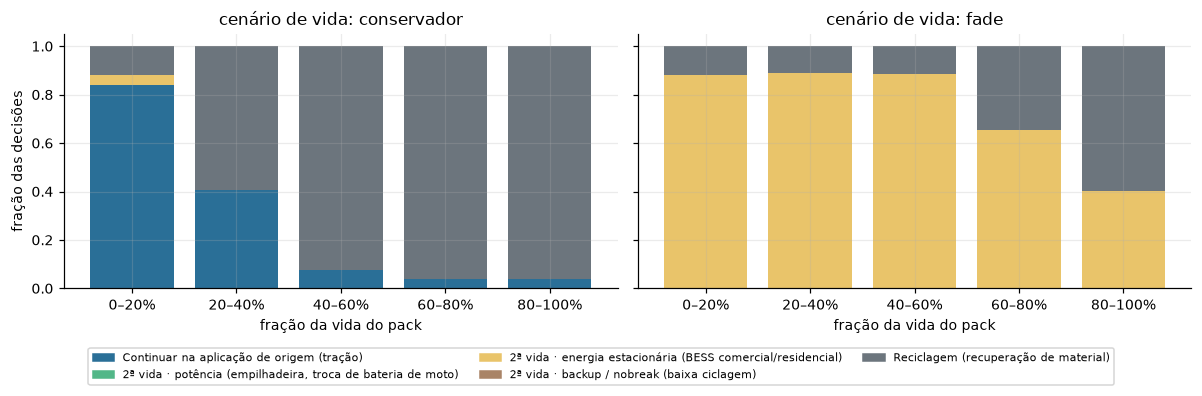

In [14]:
tables = {}
for lm in ["conservador", "fade"]:
    res = engine.fleet_decisions(replace(ST, life_model=lm, n_samples=2000))
    tables[lm] = P.decisions_table(res)

order = ["original", "potencia", "energia", "backup", "reciclagem"]
colors = {"original": "#2a6f97", "potencia": "#52b788", "energia": "#e9c46a", "backup": "#a98467", "reciclagem": "#6c757d"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, (lm, tab) in zip(axes, tables.items()):
    ct = pd.crosstab(pd.cut(tab["fração da vida"], [0, .2, .4, .6, .8, 1.0]), tab["recomendação"], normalize="index")
    ct = ct.reindex(columns=[o for o in order if o in ct.columns])
    ct.index = ["0–20%", "20–40%", "40–60%", "60–80%", "80–100%"]
    ct.plot.bar(stacked=True, ax=ax, color=[colors[c] for c in ct.columns], width=.8, legend=False)
    ax.set(title=f"cenário de vida: {lm}", xlabel="fração da vida do pack", ylabel="fração das decisões")
    ax.tick_params(axis="x", rotation=0)
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[o]) for o in order]
fig.legend(handles, [DEST[o].label for o in order], loc="lower center", ncol=3, fontsize=7, bbox_to_anchor=(.5, -.12))
plt.tight_layout()
tables["conservador"].groupby("grupo")["recomendação"].value_counts().unstack(fill_value=0)

In [15]:
t = tables["conservador"]
print("Decisões com veto de segurança:")
display(t[t["vetos"] != ""][["pack", "grupo", "ciclo", "fração da vida", "SOH P50", "vetos", "recomendação"]])
print("Decisões em que o laudo pede ensaio antes de decidir:")
display(t[t["pede ensaio"]][["pack", "grupo", "ciclo", "SOH real", "SOH P50", "valor da informação", "recomendação"]])

Decisões com veto de segurança:


,pack,grupo,ciclo,fração da vida,SOH P50,vetos,recomendação
63,22,regular_cc,309,0.698,0.820,G4 joelho de degradação,reciclagem
118,40,regular_random,93,0.903,0.843,G1 autoaquecimento,reciclagem
130,50,regular_random,114,0.898,0.880,G1 autoaquecimento,reciclagem


Decisões em que o laudo pede ensaio antes de decidir:


,pack,grupo,ciclo,SOH real,SOH P50,valor da informação,recomendação
12,02,recommissioned,41,0.929,0.934,964.376,energia
112,36,second_life,642,0.628,0.691,0.000,reciclagem
113,36,second_life,691,0.622,0.691,0.000,reciclagem
130,50,regular_random,114,0.823,0.880,0.000,reciclagem
150,54,second_life,36,0.740,0.757,0.000,reciclagem
151,54,second_life,108,0.717,0.746,0.000,reciclagem
152,54,second_life,178,0.705,0.738,0.000,reciclagem
153,54,second_life,248,0.687,0.733,0.000,reciclagem
154,54,second_life,320,0.673,0.730,0.000,reciclagem
155,54,second_life,344,0.666,0.730,0.000,reciclagem


## 7. Incerteza vira preço: garantia como produto

A Relectrify oferecia 4 anos de garantia contra 6–10 de sistemas novos porque não sabia precificar o risco
(Dossiê §3.1). Aqui, o mesmo pack e o mesmo SOH central, com intervalos cada vez mais largos: o prêmio de
garantia que fecha a conta cresce com a incerteza. **Um laudo melhor é, literalmente, garantia mais barata.**

,cenário,largura P10–P90 (p.p.),P(falha na garantia),prêmio (R$),VPL potência (R$)
0,conservador,3.00,0.04,370.64,1340.74
1,fade,3.00,0.00,0.00,2926.39
2,conservador,6.01,0.04,370.41,1251.89
3,fade,6.01,0.00,0.00,2785.77
4,conservador,12.01,0.05,481.97,934.85
5,fade,12.01,0.01,114.63,2394.47
6,conservador,18.02,0.10,1006.98,184.38
7,fade,18.02,0.06,658.31,1586.34
8,conservador,24.03,0.16,1663.20,-690.75
9,fade,24.03,0.13,1330.56,675.07


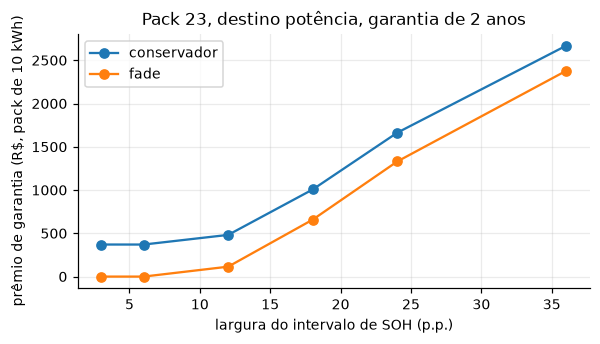

In [16]:
pack = "23"; c = engine.decision_points(pack, (0.1,))[0]
snap, _ = engine.snapshot(pack, c)
p10, p50, p90 = snap.soh_q
out = []
for k in [0.5, 1, 2, 3, 4, 6]:
    s2 = replace(snap, soh_q=(p50 - (p50 - p10) * k, p50, p50 + (p90 - p50) * k))
    for lm in ["conservador", "fade"]:
        res = route(s2, engine.stress, replace(ST, life_model=lm, n_samples=4000))
        row = {x["destino"]: x for x in res["destinos"]}["potencia"]
        out.append({"cenário": lm, "largura P10–P90 (p.p.)": (s2.soh_q[2] - s2.soh_q[0]) * 100,
                    "P(falha na garantia)": row["p_falha_garantia"], "prêmio (R$)": row["premio_garantia"],
                    "VPL potência (R$)": row["vpl_medio"]})
g = pd.DataFrame(out)
fig, ax = plt.subplots(figsize=(6, 3))
for lm, gg in g.groupby("cenário"):
    ax.plot(gg["largura P10–P90 (p.p.)"], gg["prêmio (R$)"], "o-", label=lm)
ax.set(xlabel="largura do intervalo de SOH (p.p.)", ylabel="prêmio de garantia (R$, pack de 10 kWh)",
       title=f"Pack {pack}, destino potência, garantia de {DEST['potencia'].warranty_years:.0f} anos")
ax.legend()
g.round(2)

## 8. Fechando o laço: o que a segunda vida realmente entregou

No dataset, os packs de origem rodaram até falhar e as células sobreviventes foram remontadas. Comparamos a
vida que o roteador preveria **no momento da aposentadoria** (na corrente real da segunda vida) com os ciclos
que o pack remontado de fato entregou — uma miniatura da fase F2 do dossiê.

In [17]:
loop = P.closed_loop(engine)
loop.round(2)

,pack 2ª vida,pack de origem,corrente 1ª vida (A),corrente 2ª vida (A),SOH origem P50,SOH início 2ª vida (real),SOH fim 2ª vida (real),EFC previsto só fade (P50),EFC previsto conservador (P10–P90),EFC conservador P50,EFC entregue na 2ª vida
0,13,00,16.82,9.90,0.80,0.76,0.68,319.02,3–172,39.69,230.28
1,13,11,9.85,9.90,0.72,0.76,0.68,124.29,4–175,39.07,230.28
2,36,23,15.09,7.52,0.81,0.78,0.62,747.20,169–499,304.90,478.15
3,36,52,15.12,7.52,0.80,0.78,0.62,688.52,0–259,35.53,478.15
4,54,22,13.75,4.89,0.77,0.76,0.67,631.35,46–777,631.35,250.86
5,54,31,13.70,4.89,0.73,0.76,0.67,365.38,21–382,63.62,250.86


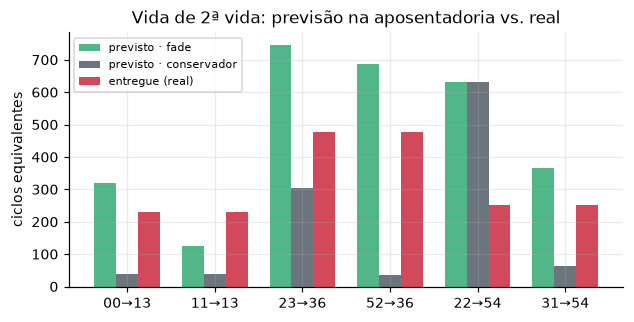

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 3))
xl = np.arange(len(loop))
ax.bar(xl - .25, loop["EFC previsto só fade (P50)"], .25, label="previsto · fade", color="#52b788")
ax.bar(xl, loop["EFC conservador P50"], .25, label="previsto · conservador", color="#6c757d")
ax.bar(xl + .25, loop["EFC entregue na 2ª vida"], .25, label="entregue (real)", color="#d1495b")
ax.set_xticks(xl, [f"{a}→{b}" for a, b in zip(loop["pack de origem"], loop["pack 2ª vida"])])
ax.set(ylabel="ciclos equivalentes", title="Vida de 2ª vida: previsão na aposentadoria vs. real")
ax.legend(fontsize=7)

**Leitura.** Nenhum dos dois cenários acerta sozinho: em **4 dos 6 pares** a vida real fica entre o
*conservador* e o *só fade*. O *só fade* erra entre ~0,5× e ~2,5× do real; o *conservador* costuma subestimar
bastante (e superestima um par). Por isso o protótipo mostra os dois cenários lado a lado, em vez de fingir
um número.
São só seis pares origem→destino (três packs remontados): o suficiente para mostrar o laço funcionando e
insuficiente para calibrar. É exatamente o dado que a fase F2 precisa gerar.

## 9. Teste de falsificação #2: segunda vida em quantidade suficiente, ou a reciclagem domina?

Decisão tomada na **aposentadoria** de cada pack (≈90% da vida), variando o frete de carga perigosa e o
preço dos produtos novos (a bateria nova fica mais barata com o tempo — Guan et al. 2025).

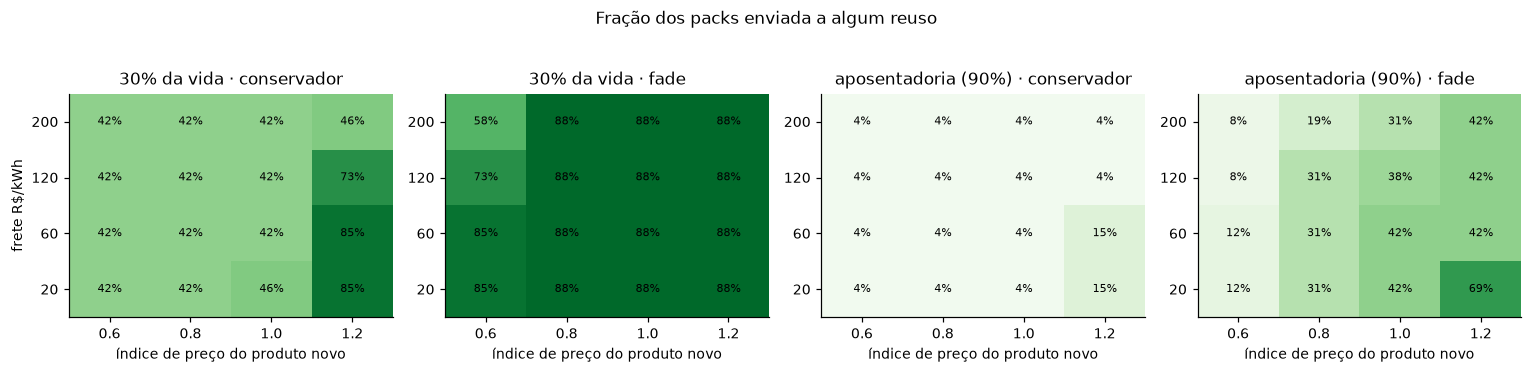

In [19]:
retire = [(p, engine.decision_points(p, (0.9,))[0]) for p in sorted(d["pack"].unique())]
early = [(p, engine.decision_points(p, (0.3,))[0]) for p in sorted(d["pack"].unique())]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
grids = {}
for i, (moment, pts) in enumerate([("30% da vida", early), ("aposentadoria (90%)", retire)]):
    for j, lm in enumerate(["conservador", "fade"]):
        grid = P.reuse_share_grid(engine, pts, life_model=lm, base=ST)
        grids[(moment, lm)] = grid
        piv = grid.pivot(index="frete R$/kWh", columns="índice de preço do novo", values="fração para reuso")
        ax = axes[2 * i + j]
        im = ax.imshow(piv.values, cmap="Greens", vmin=0, vmax=1, origin="lower", aspect="auto")
        ax.grid(False)
        ax.set_xticks(range(piv.shape[1]), piv.columns); ax.set_yticks(range(piv.shape[0]), piv.index)
        for (a, b), v in np.ndenumerate(piv.values):
            ax.text(b, a, f"{v:.0%}", ha="center", va="center", fontsize=7)
        ax.set(title=f"{moment} · {lm}", xlabel="índice de preço do produto novo", ylabel="frete R$/kWh" if j == 0 and i == 0 else "")
plt.suptitle("Fração dos packs enviada a algum reuso", y=1.04)
plt.tight_layout()

**Leitura.** Na **aposentadoria** (~90% da vida) a reciclagem domina no cenário **conservador**: só 5,3% dos
packs vão para reuso na média da grade (4% a 15% conforme a célula) — a conclusão a que a Relectrify chegou na
prática e que Guan et al. (2025) registram ("long payback periods", "marketable and profitable business models
are absent"). No **só fade** isso não se sustenta: a média sobe para 31,3% e chega a 69% na célula mais
favorável (frete baixo, produto novo caro). É a correção de preços de 18/09/2026 aparecendo — com o sistema
estacionário a R$ 3.100/kWh, a 2ª vida em energia continua lucrativa até tarde **se** a vida no destino for a
do cenário otimista.

**Aos 30% da vida**, 42–88% dos packs vão para reuso, nos dois cenários. O que mais pesa é o **momento** da
decisão e o preço do produto novo que o reuso substitui; o frete pesa menos (e só muda o resultado quando o
produto novo é caro). Com bateria nova ficando mais barata (índice < 1), a janela encolhe. Isso reforça a tese
de que o produto é a **decisão no momento certo**, não a triagem do que já sobrou — mas mostra também que
**quando** essa janela fecha depende do modelo de vida, não do preço. É o que a seção 10 mede.

## 10. A janela de realocação: até quando ainda vale reusar

A seção 9 mostrou que na aposentadoria a reciclagem domina. Se a decisão de destino tem valor, ele está
**antes**. Aqui medimos, pack a pack, onde fica essa fronteira: o roteador é aplicado em 14 pontos da vida
de cada pack (de 8% a 97%), sempre fora da amostra, e registramos o **último ponto em que algum destino de
reuso ainda vence a reciclagem** (`pipeline.decision_windows`).

Um cuidado de leitura: "reuso" inclui **continuar na aplicação de origem** (tração). Por isso separamos duas
janelas — a de reuso em geral e a de **segunda vida** (potência, energia ou backup), que é a realocação
propriamente dita.

In [20]:
SECOND_LIFE_DEST = ("potencia", "energia", "backup")
windows = {lm: P.decision_windows(engine, life_model=lm, base=ST) for lm in ["conservador", "fade"]}

def _close_2nd(traj):
    v = [t["fracao"] for t in traj if t["rec"] in SECOND_LIFE_DEST]
    return max(v) if v else np.nan

rows = []
for lm, w in windows.items():
    w["fecha_2a_vida"] = w["trajetoria"].apply(_close_2nd)
    recs = pd.Series([t["rec"] for tr in w["trajetoria"] for t in tr])
    v, v2 = w["fecha_em"].dropna(), w["fecha_2a_vida"].dropna()
    rows.append({"cenário": lm,
                 "packs com janela": f"{len(v)} de {len(w)}",
                 "fecha · mediana": f"{v.median():.0%}",
                 "fecha · quartis": f"{v.quantile(.25):.0%}–{v.quantile(.75):.0%}",
                 "sem janela": ", ".join(w.loc[w["fecha_em"].isna(), "pack"]),
                 "pontos de reuso: tração": int((recs == "original").sum()),
                 "pontos de reuso: 2ª vida": int(recs.isin(SECOND_LIFE_DEST).sum()),
                 "packs com janela de 2ª vida": int(len(v2)),
                 "janela de 2ª vida · mediana": f"{v2.median():.0%}" if len(v2) else "—"})
window_summary = pd.DataFrame(rows).set_index("cenário").T
window_summary

cenário,conservador,fade
packs com janela,22 de 26,23 de 26
fecha · mediana,28%,90%
fecha · quartis,22%–33%,70%–96%
sem janela,"13, 20, 36, 54","13, 36, 54"
pontos de reuso: tração,92,2
pontos de reuso: 2ª vida,4,257
packs com janela de 2ª vida,2,23
janela de 2ª vida · mediana,15%,90%


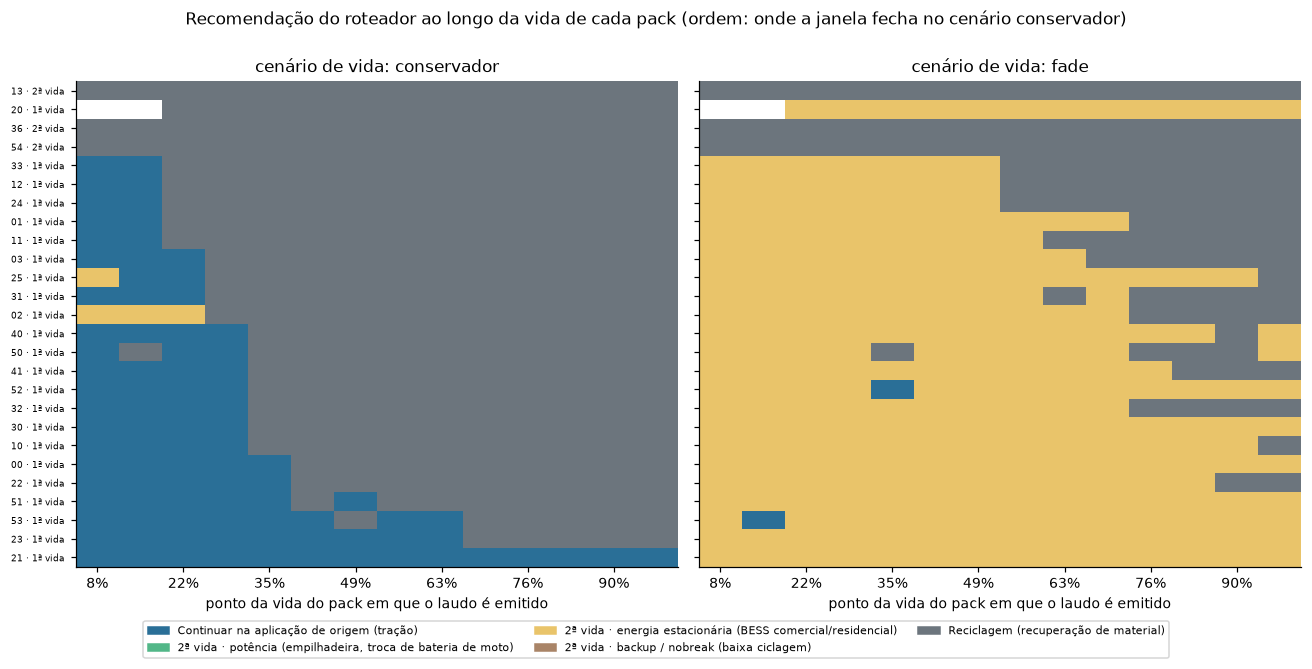

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), sharey=True)
code_of = {k: i for i, k in enumerate(order)}
from matplotlib.colors import ListedColormap
cmap = ListedColormap([colors[k] for k in order])
# a mesma ordem de packs nos dois painéis (eixo y compartilhado): pela janela do cenário conservador
pack_order = (windows["conservador"].assign(_f=windows["conservador"]["fecha_em"].fillna(-1))
              .sort_values(["_f", "pack"])["pack"].tolist())
for ax, (lm, w) in zip(axes, windows.items()):
    w = w.set_index("pack").loc[pack_order].reset_index()
    # packs curtos têm menos de 14 pontos distintos: cada ponto vai para a coluna da fração mais próxima
    grid = np.linspace(0.08, 0.97, 14)
    M = np.full((len(w), len(grid)), np.nan)
    for i, tr in enumerate(w["trajetoria"]):
        for t in tr:
            M[i, int(np.abs(grid - t["fracao"]).argmin())] = code_of[t["rec"]]
    ax.imshow(np.ma.masked_invalid(M), cmap=cmap, vmin=-.5, vmax=len(order) - .5, aspect="auto")
    ax.grid(False)
    ax.set_xticks(range(len(grid))[::2], [f"{f:.0%}" for f in grid[::2]])
    ax.set_yticks(range(len(w)), [f"{p} · {GROUP_LABEL[g].split(' ·')[0]}" for p, g in zip(w["pack"], w["grupo"])], fontsize=6)
    ax.set(title=f"cenário de vida: {lm}", xlabel="ponto da vida do pack em que o laudo é emitido")
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[o]) for o in order]
fig.legend(handles, [DEST[o].label for o in order], loc="lower center", ncol=3, fontsize=7, bbox_to_anchor=(.5, -.06))
plt.suptitle("Recomendação do roteador ao longo da vida de cada pack (ordem: onde a janela fecha no cenário conservador)", y=1.0)
plt.tight_layout()

**Leitura.**

- **A janela existe, mas onde ela fecha depende do cenário de vida.** A última vez em que algum reuso vence a
  reciclagem fica, na mediana, em **28% da vida** (quartis 22%–33%) no cenário conservador e em **90%**
  (70%–96%) no só fade. Os três packs remontados (13, 36, 54) não abrem janela em nenhum cenário: os gates
  G5/G6 os bloqueiam por incerteza. No conservador, o pack 20 (o mais curto, 29 ciclos) também não abre.
- **É o modelo de vida que decide, não o preço.** Com as premissas antigas (`v0_ilustrativo`) a mediana ia de
  28% a 49%; com os preços corrigidos ela vai de 28% a **90%**. O conservador não se moveu um ponto — ali a
  janela é determinada pela elegibilidade (piso de SOH) e pela vida até a falha, não pelo valor do produto
  substituído. O só fade quase dobrou. **Essa dispersão é o maior resultado negativo do protótipo:** o
  intervalo honesto é 28%–90% da vida, e nada nos dados disponíveis o estreita.
- **E "reuso" quer dizer coisas diferentes nos dois cenários.** No conservador, dos 96 pontos em que o reuso
  vence, 92 são "continuar na aplicação de origem"; só **2 packs** chegam a receber recomendação de 2ª vida, e
  essa janela fecha na mediana em **15%** da vida. No só fade é o contrário: 257 dos 259 pontos de reuso são 2ª
  vida (quase toda em energia estacionária, o destino cujo preço foi corrigido), e a janela de 2ª vida fecha em
  **90%**.
- **Por que os cenários divergem tanto.** O conservador limita a vida no destino pela falha abrupta do ensaio
  acelerado; aos 30% da vida ele já manda 15 dos 26 packs para reciclagem. O laço fechado (seção 8) mostrou que
  esse cenário costuma subestimar a vida real e que o só fade às vezes superestima — a vida real fica entre os
  dois na maioria dos pares. Por isso a saída aqui é um intervalo, não um número. **O que sobrevive aos dois
  cenários** é a direção: em ambos, decidir na aposentadoria é pior do que decidir antes. **O que não
  sobrevive** é "a janela fecha aos 28%" — isso é um resultado do cenário conservador, não do protótipo.
- **O que resolveria.** Escolher entre os cenários exige dado de degradação de bateria real em 2ª vida, na taxa
  C do destino. Não existe neste dataset, e é a primeira coisa que a fase F2 precisa medir.

## 11. Vale pagar por reparo antes de decidir o destino?

Reparo e remanufatura não são destinos: são **ações** que mudam o ativo, e só depois se decide para onde
ele vai. Modelamos a ação como um ganho de SOH (*uplift*) aplicado aos três quantis — trocar o módulo pior
puxa a capacidade do pack, que segue a pior célula (o "efeito barril", Wang et al. 2023, o mesmo mecanismo
dos packs remontados deste dataset). Os gates continuam valendo: um veto de segurança não se compra com reparo.

A saída é o **break-even** — quanto vale pagar pela intervenção (VPL do melhor destino após o reparo menos
o VPL sem reparo) —, não um preço de reparo, que exigiria cotação. O *uplift* também não é calibrado: é
varrido. Não há packs reparados neste dataset; calibrá-lo é trabalho da F2 (`pipeline.repair_frontier`).

In [22]:
frontier = {lm: P.repair_frontier(engine, life_model=lm, base=ST) for lm in ["conservador", "fade"]}
rows = []
for lm, rf in frontier.items():
    for mo, g in rf[rf["uplift_pp"] == 4].groupby("momento"):
        base = g["destino_base"].value_counts()
        rows.append({"cenário": lm, "momento": mo,
                     "break-even mediano (R$)": g["break_even_reparo_brl"].median(),
                     "break-even máximo (R$)": g["break_even_reparo_brl"].max(),
                     "reparo muda o destino": f"{int(g['muda_destino'].sum())} de {len(g)}",
                     "destino base = reciclagem": f"{int(base.get('reciclagem', 0))} de {len(g)}"})
repair_summary = pd.DataFrame(rows).set_index(["cenário", "momento"])
display(Markdown(f"**Ganho de 4 p.p. de SOH, pack de {ST.economics.pack_kwh:.0f} kWh**"))
repair_summary.round(0)

**Ganho de 4 p.p. de SOH, pack de 10 kWh**

break-even mediano (R$)  break-even máximo (R$)  \
cenário     momento                                                        
conservador 30% da vida                    656.0                  1514.0   
            60% da vida                      0.0                  1649.0   
            90% da vida                      0.0                   664.0   
fade        30% da vida                   1759.0                  1971.0   
            60% da vida                   1777.0                  2404.0   
            90% da vida                   1090.0                  2824.0   

                        reparo muda o destino destino base = reciclagem  
cenário     momento                                                      
conservador 30% da vida               9 de 26                  15 de 26  
            60% da vida               3 de 26                  24 de 26  
            90% da vida               0 de 26                  25 de 26  
fade        30% da vida               0 de 26                   3 de 26  
            60% da vida               4 de 26                   7 de 26  
            90% da vida               4 de 26                  16 de 26

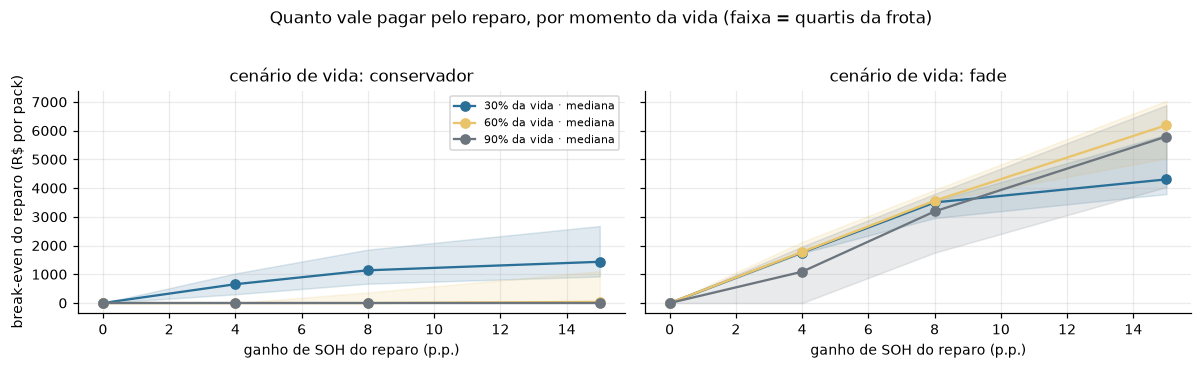

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
mcolor = {"30% da vida": "#2a6f97", "60% da vida": "#e9c46a", "90% da vida": "#6c757d"}
for ax, (lm, rf) in zip(axes, frontier.items()):
    for mo, g in rf.groupby("momento"):
        s = g.groupby("uplift_pp")["break_even_reparo_brl"]
        ax.plot(s.median().index, s.median().values, "o-", color=mcolor[mo], label=f"{mo} · mediana")
        ax.fill_between(s.median().index, s.quantile(.25).values, s.quantile(.75).values, color=mcolor[mo], alpha=.15)
    ax.set(title=f"cenário de vida: {lm}", xlabel="ganho de SOH do reparo (p.p.)")
axes[0].set_ylabel("break-even do reparo (R$ por pack)")
axes[0].legend(fontsize=7)
plt.suptitle("Quanto vale pagar pelo reparo, por momento da vida (faixa = quartis da frota)", y=1.03)
plt.tight_layout()

**Leitura.**

- **Conservador:** um ganho de 4 p.p. de SOH vale **R$ 656** na mediana aos 30% da vida (máx. R$ 1.514; muda o
  destino em 9 de 26 packs) e **R$ 0** aos 60% e aos 90%. Mesmo com 15 p.p., o pack mediano aposentado não
  paga reparo (mediana R$ 0 aos 90%).
- **Só fade:** o valor não cai. Com 4 p.p., **R$ 1.759** aos 30%, **R$ 1.777** aos 60% e ainda **R$ 1.090** aos
  90%. Com um ganho grande (15 p.p.), o reparo vale **R$ 5.796** aos 90% e muda o destino de 13 dos 26 packs.
  Ou seja, "não se paga reparo em pack aposentado" é uma conclusão do cenário conservador, não do motor.
- **Coerente com a janela, não independente dela.** O reparo passa pelo mesmo roteador e pelo mesmo modelo de
  vida, e os dois resultados se movem juntos: no conservador a reciclagem já é o destino base em 24–25 de 26
  packs aos 60–90%, então um ganho moderado de SOH não muda a decisão e o break-even vai a zero por construção;
  no só fade ela é o destino base em 7 e 16 de 26, e sobra margem para o reparo comprar. É a mesma conclusão da
  seção 10 vista por outro ângulo, não uma segunda prova.
- **O que falta para virar número de negócio:** o *uplift* é varrido, não medido, e o break-even é o teto do que
  vale pagar, não o preço do reparo. Os dois dependem de packs reparados reais (F2).

## 12. Limitações — ditas antes da banca

| limitação | por que importa | o que faria na F1/F2 |
|---|---|---|
| **Íon-lítio 18650, não Ni-MH** | o insumo imediato da Toyota no Brasil é Ni-MH (Análise §5) | repetir o pipeline em packs Ni-MH do HV Recovery |
| **Pack de 2 células, não pack automotivo** | todos os artigos do acervo também validam em célula (Análise §4) | dados de módulo/pack com BMS real |
| **Ensaio acelerado a 4–8 C, ~100 °C** | vida em destinos a 0,2–1 C é extrapolação | ensaios em taxa realista; dataset Stanford–Relyion (#2) |
| **Falha abrupta sem precursor elétrico** | vida residual sai com intervalo largo | sensores de gás/deformação (H1/H2) |
| **Só três packs remontados** | calibração da 2ª vida é frágil | Zenodo 14859405 (86 células, 1ª e 2ª vida) |
| **Sem EIS nem sensores de gás** | gates térmicos são proxies | bancada H2 com EIS rápido (Wang et al. 2023: ~6 min) |
| **Economia por perfil de premissas, não por cotação** | os preços do perfil `bev_revisado` vêm de imprensa (confiança média), e frete e regulação brasileiros não têm fonte pública (Dossiê §6; `PREMISSAS.md`) | cotações reais, REN 1.161/2026, UL 1974 |
| **A posição da janela não é resolvida** (28% a 90% da vida, conforme o modelo de vida) | é a maior incerteza do protótipo: muda a decisão de quando realocar, e nenhum preço a resolve | degradação medida em 2ª vida real, na taxa C do destino |
| **Offset de termopar por pack** | limite térmico absoluto é inútil neste dataset | calibração de sensor no passaporte |
| **VPL da reciclagem negativo com as premissas atuais** (−R$ 300 por pack de 10 kWh) | o motor escolhe o menor prejuízo, não o maior lucro; o valor de material decide o sinal | cotar valor de material e processo de reciclagem |
| **Reparo não calibrado** | o ganho de SOH é varrido, não medido; o break-even é teto, não preço | packs reparados reais (F2) |

**O que o protótipo mostra, apesar disso:** o encadeamento inteiro funciona sobre dados reais — laudo
sem ciclagem completa com erro de ~1,7 p.p. fora da amostra, vetos de segurança com evidência, destino por
VPL sob incerteza, garantia precificada pela incerteza, e um laudo que sabe dizer "não sei, ensaie".